In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\NEHA\Downloads\train.csv....csv")

print(df.shape)

(9800, 18)


In [2]:
print("Columns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     

In [3]:
print("Customer Segments:")
print(df["Segment"].value_counts())

print("\nProduct Categories:")
print(df["Category"].value_counts())

print("\nSales Summary:")
print(df["Sales"].describe())

Customer Segments:
Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

Product Categories:
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

Sales Summary:
count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

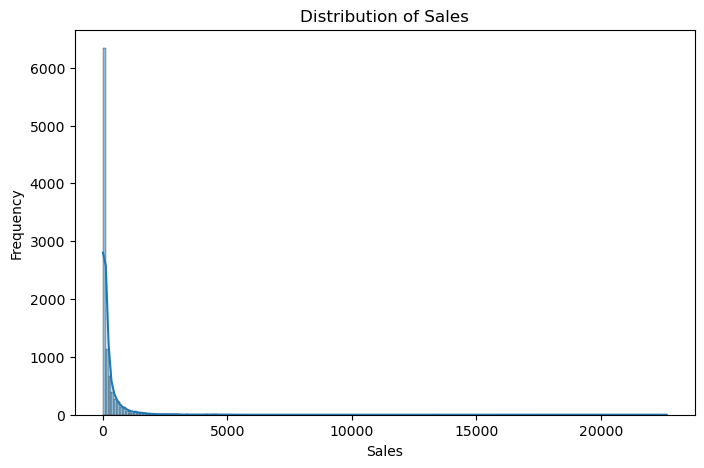

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [8]:
from scipy.stats import shapiro

stat, p = shapiro(df["Sales"])

print("Shapiro-Wilk Test")
print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Result: Sales data is not normally distributed.")
else:
    print("Result: Sales data is approximately normally distributed.")

Shapiro-Wilk Test
Statistic: 0.32263133709697467
p-value: 1.3170867537153254e-104
Result: Sales data is not normally distributed.


C:\Users\NEHA\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9800.
  res = hypotest_fun_out(*samples, **kwds)


In [9]:
from scipy.stats import kstest
import numpy as np

sales = df["Sales"]

stat, p = kstest(
    sales,
    "norm",
    args=(sales.mean(), sales.std())
)

print("Kolmogorov-Smirnov Test")
print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Result: Sales data differs significantly from a normal distribution.")
else:
    print("Result: Sales data is approximately normally distributed.")

Kolmogorov-Smirnov Test
Statistic: 0.3566341019280328
p-value: 0.0
Result: Sales data differs significantly from a normal distribution.


In [10]:
consumer_sales = df[df["Segment"] == "Consumer"]["Sales"]
corporate_sales = df[df["Segment"] == "Corporate"]["Sales"]

print("Consumer observations:", len(consumer_sales))
print("Corporate observations:", len(corporate_sales))

Consumer observations: 5101
Corporate observations: 2953


In [11]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    consumer_sales,
    corporate_sales,
    equal_var=False
)

print("Two-Sample t-test (Welch's t-test)")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: There is a statistically significant difference between the two group means.")
else:
    print("Result: There is no statistically significant difference between the two group means.")

Two-Sample t-test (Welch's t-test)
t-statistic: -0.5866199979710516
p-value: 0.5574807659382968
Result: There is no statistically significant difference between the two group means.


In [12]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    consumer_sales,
    corporate_sales,
    alternative="two-sided"
)

print("Mann-Whitney U Test")
print("U-statistic:", u_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: There is a statistically significant difference between the two groups.")
else:
    print("Result: There is no statistically significant difference between the two groups.")

Mann-Whitney U Test
U-statistic: 7474248.5
p-value: 0.5682632920001747
Result: There is no statistically significant difference between the two groups.


In [14]:
from scipy import stats

In [15]:
consumer = df[df["Segment"] == "Consumer"]["Sales"]
corporate = df[df["Segment"] == "Corporate"]["Sales"]
home_office = df[df["Segment"] == "Home Office"]["Sales"]

f_stat, p_value = stats.f_oneway(
    consumer,
    corporate,
    home_office
)

print("One-Way ANOVA")
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: There is a statistically significant difference among the group means.")
else:
    print("Result: There is no statistically significant difference among the group means.")

One-Way ANOVA
F-statistic: 0.5874032714436911
p-value: 0.5557881652680301
Result: There is no statistically significant difference among the group means.


In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=df["Sales"],
    groups=df["Segment"],
    alpha=0.05
)

print(tukey_result)

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower    upper  reject
-------------------------------------------------------------
 Consumer   Corporate   8.0849 0.8424 -25.8822 42.0521  False
 Consumer Home Office  18.3375 0.5419 -22.3924 59.0674  False
Corporate Home Office  10.2526 0.8506 -34.0942 54.5993  False
-------------------------------------------------------------


In [17]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "Sales ~ C(Segment) + C(Category) + C(Segment):C(Category)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                              sum_sq      df           F         PR(>F)
C(Segment)              4.428525e+05     2.0    0.594134   5.520604e-01
C(Category)             1.954618e+08     2.0  262.232784  1.146147e-111
C(Segment):C(Category)  3.088177e+06     4.0    2.071559   8.172558e-02
Residual                3.648983e+09  9791.0         NaN            NaN


## Hypotheses

### One-Way ANOVA

**Null hypothesis (H0):** The mean Sales are equal across Consumer, Corporate, and Home Office segments.

**Alternative hypothesis (H1):** At least one customer segment has a different mean Sales.

### Two-Way ANOVA

**Null hypothesis (H0):** Segment, Category, and their interaction have no statistically significant effect on Sales.

**Alternative hypothesis (H1):** At least one of these factors or their interaction has a statistically significant effect on Sales.

**Significance level (alpha):** 0.05


## Confidence Intervals

A 95% confidence level was used for statistical inference.

For the One-Way ANOVA analysis, the group means were:

- Consumer: 225.07
- Corporate: 233.15
- Home Office: 243.40

The confidence intervals for the group means were:

- Consumer: 208.90 to 241.23
- Corporate: 211.50 to 254.80
- Home Office: 207.60 to 279.21


## Findings

### Normality Tests

The Shapiro-Wilk test indicated that Sales were not normally distributed. The Kolmogorov-Smirnov test also indicated a significant departure from normality.

The Shapiro-Wilk test produced a warning because the sample size was greater than 5,000, so its p-value should be interpreted with caution.

### Two-Sample Tests

The Welch two-sample t-test did not find a statistically significant difference in mean Sales between Consumer and Corporate segments (p = 0.5575).

The Mann-Whitney U test also did not find a statistically significant difference between these two groups (p = 0.5683).

### One-Way ANOVA

The One-Way ANOVA did not find a statistically significant difference in mean Sales across the three customer segments (F = 0.5874, p = 0.5558).

The Tukey HSD post-hoc test also found no statistically significant pairwise differences.

### Two-Way ANOVA

The main effect of Segment was not statistically significant (p = 0.5521).

The main effect of Category was statistically significant (p < 0.001).

The Segment × Category interaction was not statistically significant at the 0.05 level (p = 0.0817).

## Conclusion

The analysis did not find evidence of a statistically significant difference in Sales across customer segments. However, Category showed a statistically significant main effect on Sales in the Two-Way ANOVA.

All statistical tests were evaluated using a significance level of 0.05.